In [3]:
pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.3 MB 5.4 MB/s eta 0:00:07
   - -------------------------------------- 1.8/37.3 MB 4.3 MB/s eta 0:00:09
   -- ------------------------------------- 2.4/37.3 MB 4.6 MB/s eta 0:00:08
   --- ------------------------------------ 3.4/37.3 MB 4.3 MB/s eta 0:00:08
   ---- ----------------------------------- 4.5/37.3 MB 4.2 MB/s eta 0:00:08
   ----- ---------------------------------- 5.2/37.3 MB 4.2 MB/s eta 0:00:08
   ------ --------------------------------- 6.0/37.3 MB 4.1 MB/s eta 0:00:08
   ------- -------------------------------- 6.8/37.3 MB 4.1 MB/s eta 0:00:08
   -------- ------------------------------- 7.6/37.3 MB 4.1 MB/s eta 0:00:08
   -------- ------------------------------- 8.4/37.3 MB 4.0 MB/s eta 0:00:08
   --------- ------------------------------ 9.2/37.3 MB 4.0 MB/s eta 0:00:07
   ---------- ----------------------------- 10.0/37.3 MB 4.0 MB/s eta 0:00:07
   --

In [4]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 9.5 MB/s eta 0:00:01
   ----- ---------------------------------- 1.0/8.1 MB 6.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.8 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 3.5 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 3.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 3.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 3.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 3.7 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 3.6 MB/s  0:00:02

   ------------- ----

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
import os

In [2]:
# Create visuals folder
os.makedirs("visuals",exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


LOADING DATA

In [3]:
df=pd.read_csv(r"C:\Users\ns021\OneDrive\Documents\Unified mentor project  2\Palo Alto Networks.csv")

print("Data loaded successfully")
print(f"Shape:{df.shape[0]} rows, {df.shape[1]} columns")

df
df.describe()
df.info()

Data loaded successfully
Shape:1470 rows, 31 columns
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


DATA VALIDATION AND NORMALIZATION

Validating ordinal scales

In [5]:
ordinal_cols=['EnvironmentSatisfaction','JobInvolvement','JobSatisfaction',
              'RelationshipSatisfaction','WorkLifeBalance','PerformanceRating']

for col in ordinal_cols:
    print(f"{col}: min={df[col].min()},max={df[col].max()},missing={df[col].isnull().sum()}")



EnvironmentSatisfaction: min=1,max=4,missing=0
JobInvolvement: min=1,max=4,missing=0
JobSatisfaction: min=1,max=4,missing=0
RelationshipSatisfaction: min=1,max=4,missing=0
WorkLifeBalance: min=1,max=4,missing=0
PerformanceRating: min=3,max=4,missing=0


Handling missing values

In [6]:

df[ordinal_cols]=df[ordinal_cols].fillna(df[ordinal_cols].median())



Normalize using Z-Score

In [7]:
scaler=StandardScaler()
z_cols=['EnvS_z','JobInv_z','JobSat_z','RelS_z']
df[z_cols]=scaler.fit_transform(df[['EnvironmentSatisfaction','JobInvolvement',
                                    'JobSatisfaction','RelationshipSatisfaction']])

print("Data Validation and Normalization completed")

Data Validation and Normalization completed


In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EnvS_z,JobInv_z,JobSat_z,RelS_z
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,1,6,4,0,5,-0.660531,0.379672,1.153254,-1.584178
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,3,3,10,7,1,7,0.254625,-1.026167,-0.660853,1.191438
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,3,0,0,0,0,1.169781,-1.026167,0.246200,-0.658973
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,8,7,3,0,1.169781,0.379672,0.246200,0.266233
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,3,2,2,2,2,-1.575686,0.379672,-0.660853,1.191438


ENGAGEMENT INDEX CONSTRUCTION

Overall Engagement index mean:2.723


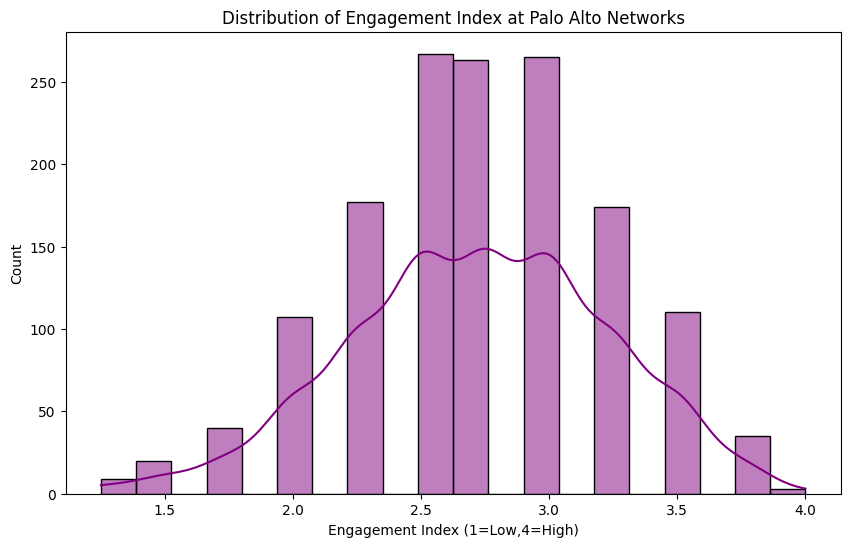

Engagement Index created andd saved


In [9]:
engagement_cols=['JobInvolvement','JobSatisfaction','EnvironmentSatisfaction','RelationshipSatisfaction']

df['EngagementIndex']=df[engagement_cols].mean(axis=1)
df['EngagementIndex_z']=df[z_cols].mean(axis=1)

print(f"Overall Engagement index mean:{df['EngagementIndex'].mean():.3f}")

plt.figure(figsize=(10,6))
sns.histplot(df['EngagementIndex'],kde=True,bins=20,color='Purple',line_kws={'color':'LightPink'})
plt.title("Distribution of Engagement Index at Palo Alto Networks")
plt.xlabel("Engagement Index (1=Low,4=High)")
plt.savefig("visuals/step2_engagement_distribution.png",dpi=300,bbox_inches='tight')
plt.show()

print("Engagement Index created andd saved")

BURNOUT RISK IDENTIFICATION

BurnoutRiskLevel
Low       756
Medium    588
High      126
Name: count, dtype: int64


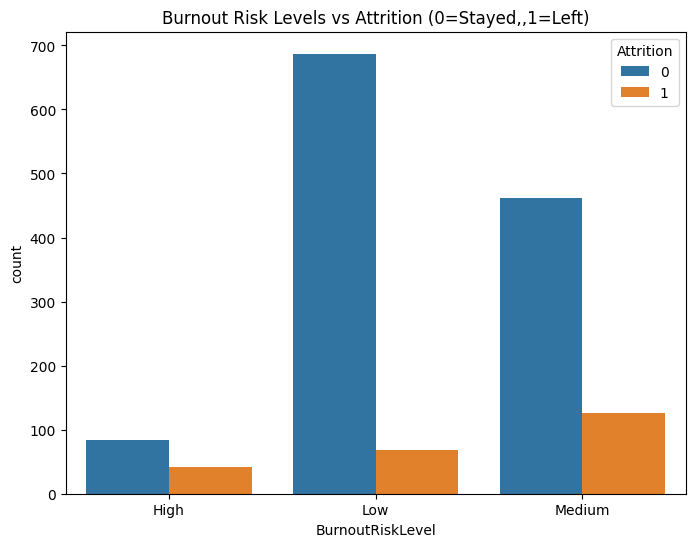

In [10]:
df['BurnoutHighRisk']=((df['OverTime']=='Yes')&(df['WorkLifeBalance']<=2)).astype(int)

conditions=[
    (df['OverTime']=='Yes')&(df['WorkLifeBalance']<=2),
    (df['OverTime']=='Yes')|(df['WorkLifeBalance']<=2)
]
df['BurnoutRiskLevel']=pd.Series(np.select(conditions,['High','Medium'],default='Low'))

print(df['BurnoutRiskLevel'].value_counts())

#Visualization
plt.figure(figsize=(8,6))
sns.countplot(x='BurnoutRiskLevel',hue='Attrition',data=df)
plt.title("Burnout Risk Levels vs Attrition (0=Stayed,,1=Left)")
plt.savefig("visuals/step3_burnout_risk_vs_attrition.png",dpi=300,bbox_inches='tight')
plt.show()

WORKLOAD & STRESS ANALYSIS

Overtime vs non-overtime employees

OverTime
No     2.699004
Yes    2.784255
Name: EngagementIndex, dtype: float64


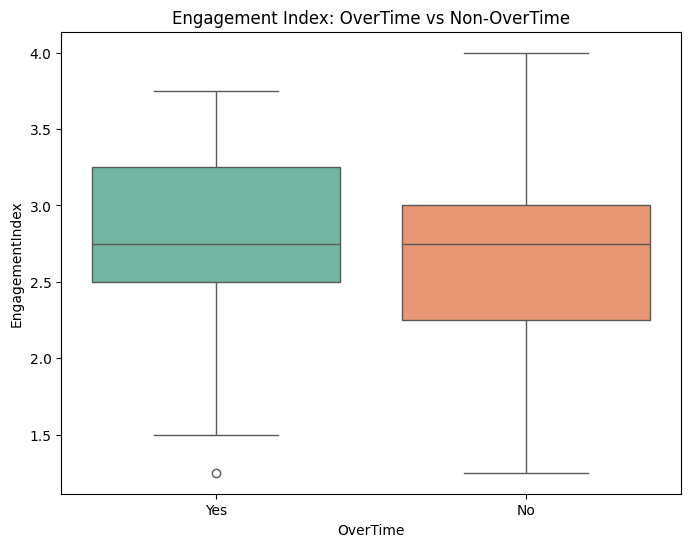

In [11]:
df['LongCommute']=df['DistanceFromHome']>10

overtime_analysis = df.groupby('OverTime')['EngagementIndex'].mean()

print(overtime_analysis)

plt.figure(figsize=(8,6))
sns.boxplot(x='OverTime',y='EngagementIndex',data=df,hue='OverTime',palette="Set2",legend=False)
plt.title("Engagement Index: OverTime vs Non-OverTime")
plt.savefig("visuals/step4_overtime_boxplot.png",dpi=300,bbox_inches='tight')
plt.show()


Travel frequency categories

BusinessTravel
Non-Travel           2.735000
Travel_Frequently    2.749097
Travel_Rarely        2.714525
Name: EngagementIndex, dtype: float64


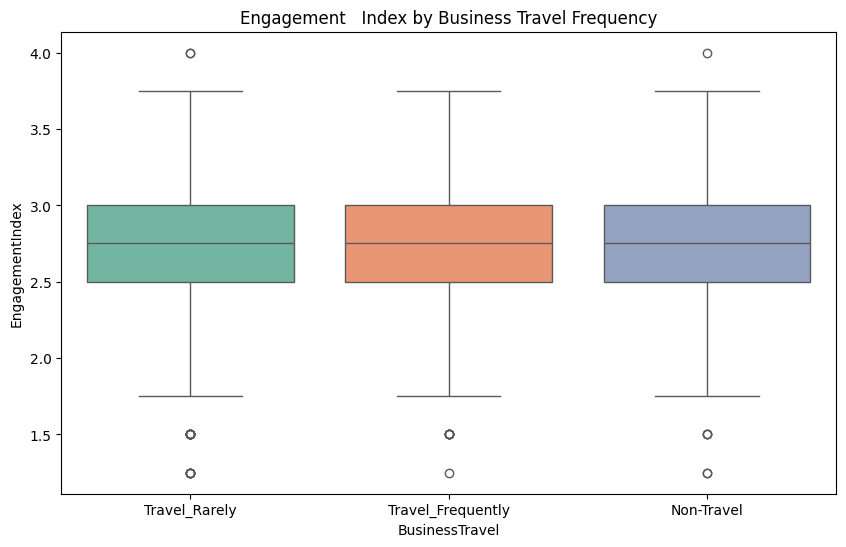

In [12]:
travel_analysis = df.groupby('BusinessTravel')['EngagementIndex'].mean()

print(travel_analysis)

plt.figure(figsize=(10,6))
sns.boxplot(x='BusinessTravel',y='EngagementIndex',data=df,hue='BusinessTravel',palette='Set2',legend=False)
plt.title("Engagement   Index by Business Travel Frequency")
plt.savefig("visuals/step4_travel_boxplot.png",dpi=300,bbox_inches='tight')
plt.show()

Long vs Short commute distances

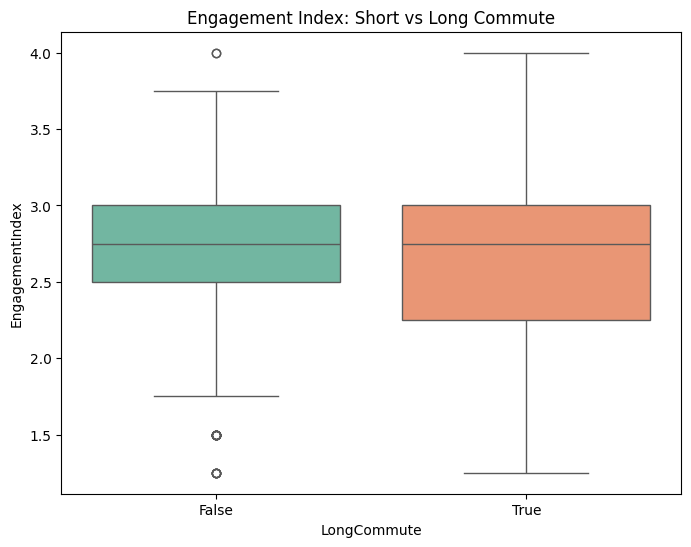

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(x='LongCommute',y='EngagementIndex',data=df,hue='LongCommute',palette="Set2",legend=False)
plt.title("Engagement Index: Short vs Long Commute")
plt.savefig("visuals/step4_commute_boxplot.png",dpi=300,bbox_inches='tight')
plt.show()

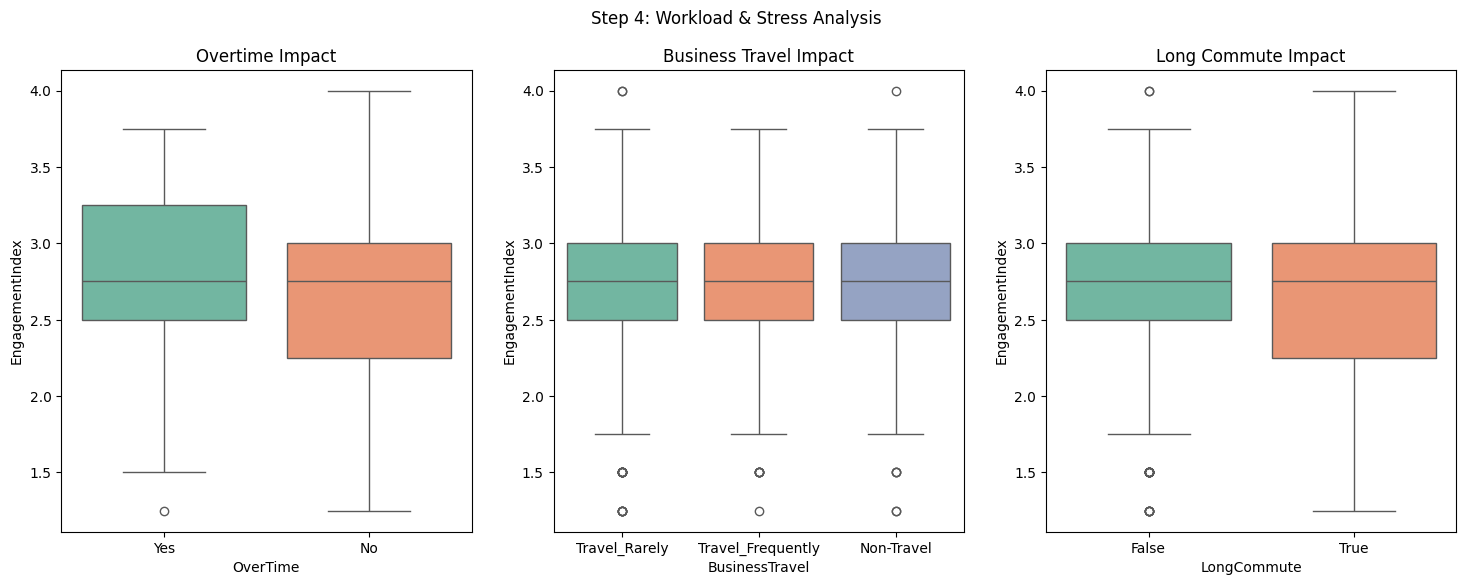

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(ax=axes[0], x='OverTime', y='EngagementIndex', data=df, hue='OverTime', palette="Set2", legend=False)
axes[0].set_title("Overtime Impact")
sns.boxplot(ax=axes[1], x='BusinessTravel', y='EngagementIndex', data=df, hue='BusinessTravel', palette="Set2", legend=False)
axes[1].set_title("Business Travel Impact")
sns.boxplot(ax=axes[2], x='LongCommute', y='EngagementIndex', data=df, hue='LongCommute', palette="Set2", legend=False)
axes[2].set_title("Long Commute Impact")
plt.suptitle("Step 4: Workload & Stress Analysis")
plt.savefig("visuals/step4_combined_workload_visuals.png", dpi=300, bbox_inches='tight')
plt.show()


CAREER-STAGE ENGAGEMENT ANALYSIS

Engagement by Job level

In [15]:
joblevel_analysis = df.groupby(
    'JobLevel'
)['EngagementIndex'].mean()

print(joblevel_analysis)

JobLevel
1    2.725599
2    2.725655
3    2.674312
4    2.783019
5    2.746377
Name: EngagementIndex, dtype: float64


Engagement by Year at company and years in current rrole

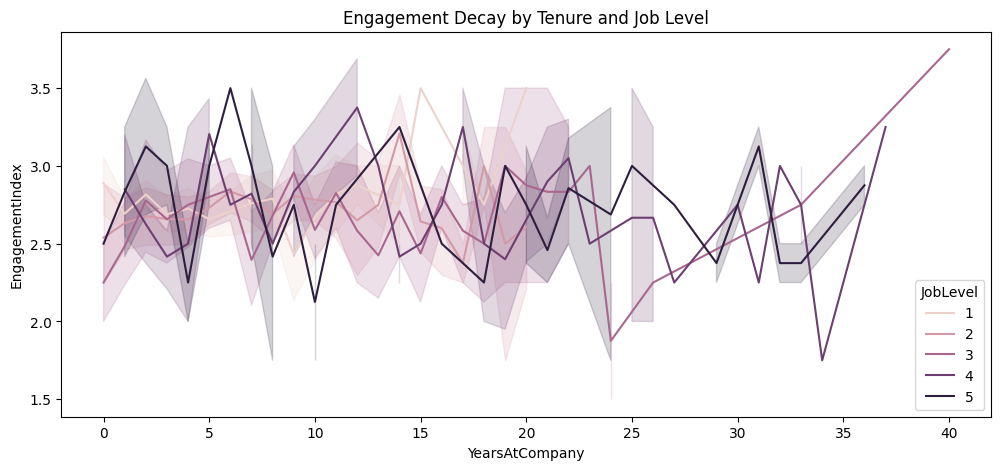

In [16]:
plt.figure(figsize=(12,5))
sns.lineplot(x='YearsAtCompany', y='EngagementIndex', hue='JobLevel', data=df, errorbar=('ci', 95))
plt.title("Engagement Decay by Tenure and Job Level")
plt.savefig("career_stagnation.png", dpi=300)
plt.show()

Stagnation-Linked disengagement

In [17]:
df['StagnationRisk'] = (df['YearsInCurrentRole'] > 3) & (df['YearsSinceLastPromotion'] > 3)
print(df.groupby('StagnationRisk')['EngagementIndex'].mean())




StagnationRisk
False    2.722363
True     2.726316
Name: EngagementIndex, dtype: float64


ENGAGEMENT VS ATTRITION


 Engagement vs Attrition Analysis

 Engagement comparison by Attrition Status:
               mean  median  count       std
Attrition                                   
0          2.763585    2.75   1233  0.482830
1          2.512658    2.50    237  0.557925


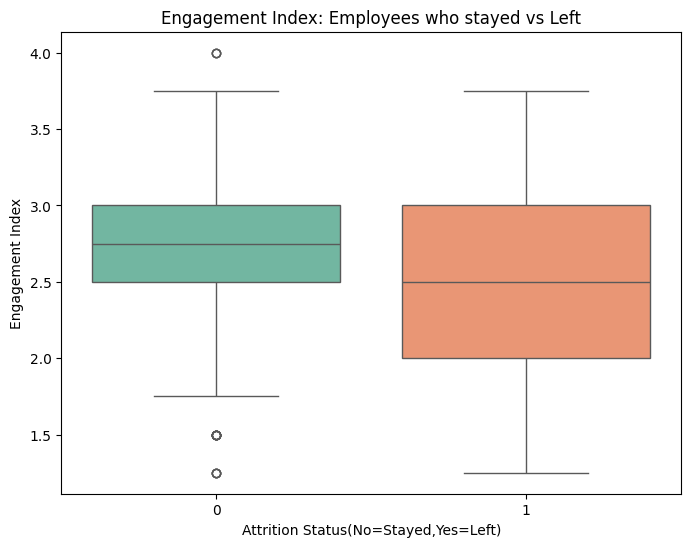

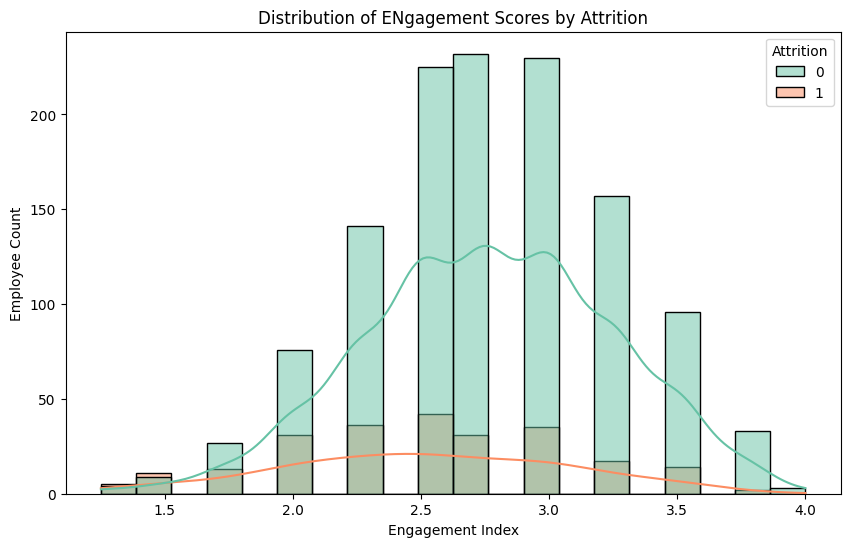

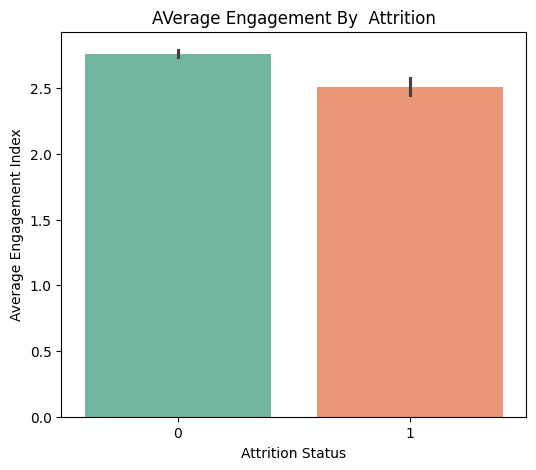


 Attrition Percentage by ENgagement Level:
Attrition              0          1
LowEngagement                      
False          88.352941  11.647059
True           77.741935  22.258065

 Interpretation
Employees who left had similar or higher engagement scores


In [27]:
print("\n Engagement vs Attrition Analysis")

# Average engagement comparison

attrition_analysis=df.groupby('Attrition')['EngagementIndex'].agg(
    ['mean','median','count','std']
)

print("\n Engagement comparison by Attrition Status:")
print(attrition_analysis)

# Boxplot Comparison

plt.figure(figsize=(8,6))

sns.boxplot(
    x='Attrition',
    y='EngagementIndex',
    data=df,
    hue='Attrition',
    palette='Set2',
    legend=False
)
plt.title("Engagement Index: Employees who stayed vs Left")

plt.xlabel("Attrition Status(No=Stayed,Yes=Left)")
plt.ylabel("Engagement Index")

plt.savefig("visuals/step6_engagement_vs_attrition_boxplot.png",dpi=300,bbox_inches='tight')

plt.show()

# Distribution PLot


plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='EngagementIndex',
    hue='Attrition',
    kde=True,
    bins=20,
    palette='Set2'
)

plt.title("Distribution of ENgagement Scores by Attrition")

plt.xlabel('Engagement Index')
plt.ylabel('Employee Count')

plt.savefig(
    "visuals/step6_engagement_distribution_attribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# Mean Engagement Visualization

plt.figure(figsize=(6,5))

sns.barplot(
    x='Attrition',
    y='EngagementIndex',
    data=df,
    hue='Attrition',
    palette='Set2',
    estimator='mean',
    errorbar=('ci',95),
    legend=False
)

plt.title("AVerage Engagement By  Attrition")

plt.xlabel("Attrition Status")
plt.ylabel("Average Engagement Index")

plt.savefig(
    "visuals/step6_avg_engagement_attrition.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Low Engagement Attrition Rate

# Create Low engagement flag
df['LowEngagement']=df['EngagementIndex']<df['EngagementIndex'].median()

low_eng_attrition=pd.crosstab(
    df['LowEngagement'],
    df['Attrition'],
    normalize='index'
) * 100

print("\n Attrition Percentage by ENgagement Level:")
print(low_eng_attrition)

# Interpretation

stayed_mean=df[df['Attrition']=='No']['EngagementIndex'].mean()
left_mean=df[df['Attrition']=='Yes']['EngagementIndex'].mean()

print("\n Interpretation")

if left_mean<stayed_mean:
    print("\n Employees who lef the organization had lower engagement scores on average")

else:
    print("Employees who left had similar or higher engagement scores")

KEY PERFORMANCE INDICATORS(KPIs)

In [31]:
# KPI 1: Engagement Index

print("Avg Engagement Index:")
print(round(df['EngagementIndex'].mean(),3))

Avg Engagement Index:
2.723


In [38]:
# KPI 2: Burnout Risk Score

# Burnout Logic: Overtime + low work life balance

burnout_rate = (
    df['BurnoutHighRisk'].mean()
) * 100

print("\nBurnout Risk Level:")
print(round(burnout_rate))


Burnout Risk Level:
9


In [32]:
# KPI 3: Work-Life Balance Index

worklife_index=df['WorkLifeBalance'].mean()

print("\n Work-Life Balance Index:")
print(round(worklife_index,3))


 Work-Life Balance Index:
2.761


In [33]:
# KPI 4: Satisfacction Stability Score

satisfaction_cols=[
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction'
]

# Standard Deviation across satisfaction dimensions
df['SatisfactionStabilityScore']=df[satisfaction_cols].std(axis=1)

print("\n Average Satisfaction Stability Score: ")
print(round(df['SatisfactionStabilityScore'].mean(),3))


 Average Satisfaction Stability Score: 
0.984


In [42]:
# KPI 5: Workload Stress Indicator

df['WorkloadStress']=((df['OverTime']=='Yes') & 
                      (df['BusinessTravel']=='Travel_Frequently')).astype(int)

workload_stress_pct=df['WorkloadStress'].mean()*100


print("\n Workload stress Indicator")
print(workload_stress_pct)


 Workload stress Indicator
5.850340136054422
